A **stochastic process** is a ordered collection of random variables, each with their own pdf. A **stationary process** has a time invariant pdf, unlike a non-stationary process. For non-stationary processes, time-averaging will not provide meaningful approximations of the process statistics. 
<br> Stochastic processes become a random variable when you fix time. It becomes a deterministic time signal when you fix the outcome (choose a point in the sample space). 
A **sample space** is the set of all possible outcomes of the random experiment. 

A **realisation** is one single outcome observed when a stochastic process unfolds over time, representing one path the process could have taken.
An **ensemble** is a collection of all of the possible outcomes or realisations that the random process could generate, defined over the same underlying probability space. <br>
<br>
**Ensemble averaging** is averaging many independent realisations from the same time index, which mixes random outcomes. **Time averaging** is averaging over one realisation over time, which mixes time evolution. For ergodic processes, these will give the same answer. <br>
<br>
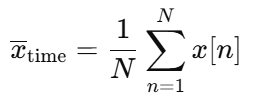
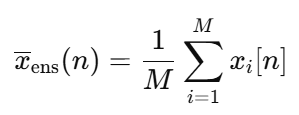

Process 1: <br>
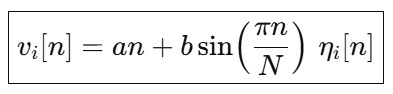

Time goes along the x axis. Realisations goes along the y axis.

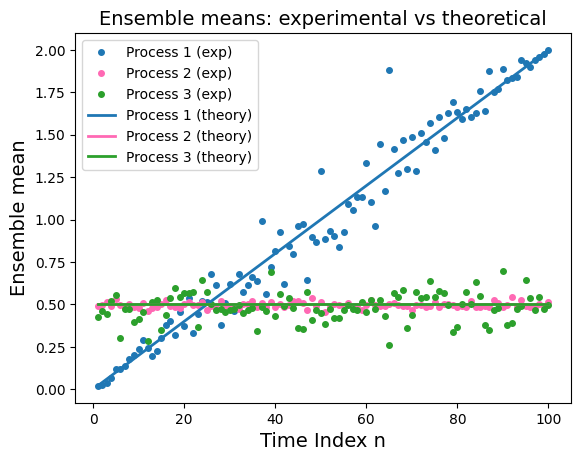

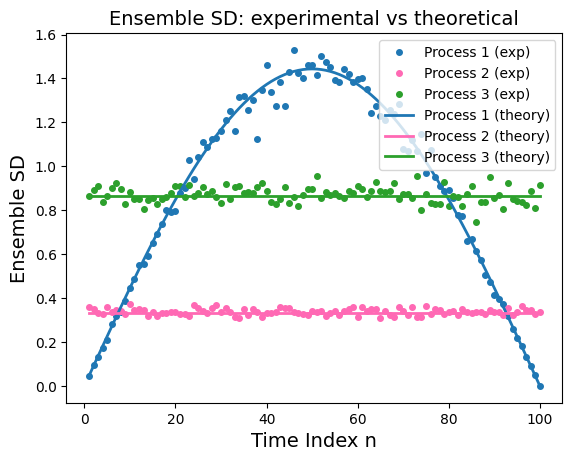

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def rp1(M, N):
    a = 0.02
    b = 5.0

    Mc = np.ones((M, 1)) * b * np.sin(np.arange(1, N + 1) * np.pi / N)
    Ac = a * np.ones((M, 1)) * np.arange(1, N + 1) # Offset

    v = (np.random.rand(M, N) - 0.5) * Mc + Ac # Zero mean noise applied to deterministic sin wave
    return v

def rp2(M, N): # All rows have the same value
    Ar = np.random.rand(M, 1) * np.ones((1, N)) # Constant in offset for each realisation.
    Mr = np.random.rand(M, 1) * np.ones((1, N)) # Constant in amplitude for each realisation.

    v = (np.random.rand(M, N) - 0.5) * Mr + Ar # Zero mean noise applied to non-deterministic noise
    return v

def rp3(M, N):
    a = 0.5 
    m = 3.0

    v = (np.random.rand(M, N) - 0.5) * m + a # All realisations are random. Same distribution across time and realisations. Ergodic process.
    return v

M = 100
N = 100

def generateSamplesAndPlots(M, N):
    v_1 = rp1(M, N)
    v_2 = rp2(M, N)
    v_3 = rp3(M, N)
    ensemble_mean_v_1 = np.mean(v_1, axis=0)
    ensemble_SD_v_1 = np.sqrt(1/(M-1) * (np.sum(np.square(v_1-ensemble_mean_v_1), axis=0)))
    ensemble_mean_v_2 = np.mean(v_2, axis=0)
    ensemble_SD_v_2 = np.sqrt(1/(M-1) * (np.sum(np.square(v_2-ensemble_mean_v_2), axis=0)))
    ensemble_mean_v_3 = np.mean(v_3, axis=0)
    ensemble_SD_v_3 = np.sqrt(1/(M-1) * (np.sum(np.square(v_3-ensemble_mean_v_3), axis=0)))

    n = np.arange(1, N + 1)
    mean_th1 = 0.02 * n
    sd_th1 = (5 / np.sqrt(12)) * np.abs(np.sin(n * np.pi / N))
    mean_th2 = 0.5 * np.ones(N)
    sd_th2 = (1/3) * np.ones(N)
    mean_th3 = 0.5 * np.ones(N)
    sd_th3 = np.sqrt(0.75) * np.ones(N)

    plt.figure()
    plt.plot(n, ensemble_mean_v_1, '.', markersize=8, label='Process 1 (exp)', color='C0')
    plt.plot(n, ensemble_mean_v_2, '.', markersize=8, label='Process 2 (exp)', color='hotpink')
    plt.plot(n, ensemble_mean_v_3, '.', markersize=8, label='Process 3 (exp)', color='C2')
    plt.plot(n, mean_th1, '-', linewidth=2, label='Process 1 (theory)', color='C0')
    plt.plot(n, mean_th2, '-', linewidth=2, label='Process 2 (theory)', color='hotpink')
    plt.plot(n, mean_th3, '-', linewidth=2, label='Process 3 (theory)', color='C2')
    plt.xlabel("Time Index n", fontsize=14)
    plt.ylabel("Ensemble mean", fontsize=14)
    plt.title("Ensemble means: experimental vs theoretical", fontsize=14)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(n, ensemble_SD_v_1, '.', markersize=8, label='Process 1 (exp)', color='C0')
    plt.plot(n, ensemble_SD_v_2, '.', markersize=8, label='Process 2 (exp)', color='hotpink')
    plt.plot(n, ensemble_SD_v_3, '.', markersize=8, label='Process 3 (exp)', color='C2')
    plt.plot(n, sd_th1, '-', linewidth=2, label='Process 1 (theory)', color='C0')
    plt.plot(n, sd_th2, '-', linewidth=2, label='Process 2 (theory)', color='hotpink')
    plt.plot(n, sd_th3, '-', linewidth=2, label='Process 3 (theory)', color='C2')
    plt.xlabel("Time Index n", fontsize=14)
    plt.ylabel("Ensemble SD", fontsize=14)
    plt.title("Ensemble SD: experimental vs theoretical", fontsize=14)
    plt.legend()
    plt.show()

generateSamplesAndPlots(M, N)

Process 1: Non-stationary in both ensemble mean and variance. Mean is a ramp function and SD is a sin function. <br>
Process 2: Ensemble statistics gives both constant mean and variance. So can be considered stationary. <br>
Process 3: Ensemble mean and SD are constant, so stationary. Same distribution across all realisations and time. <br>

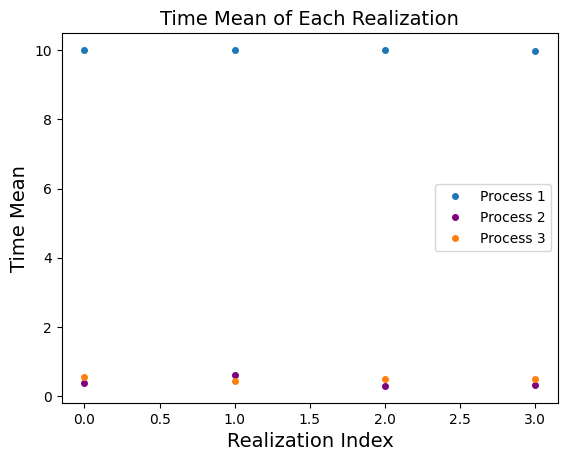

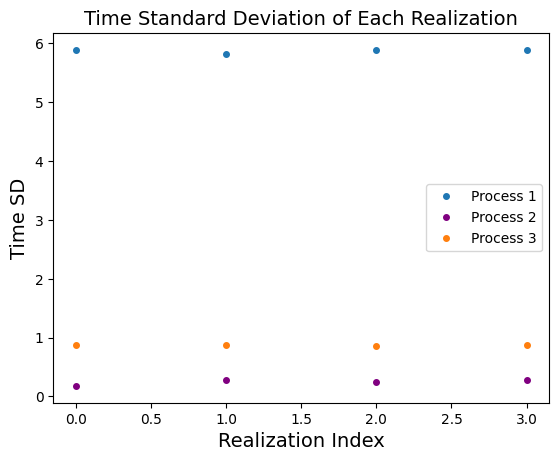

In [10]:
def rp1(M, N):
    a = 0.02
    b = 5.0

    Mc = np.ones((M, 1)) * b * np.sin(np.arange(1, N + 1) * np.pi / N)
    Ac = a * np.ones((M, 1)) * np.arange(1, N + 1) # Offset

    v = (np.random.rand(M, N) - 0.5) * Mc + Ac # Zero mean noise applied to deterministic sin wave
    return v

def rp2(M, N): # All rows have the same value
    Ar = np.random.rand(M, 1) * np.ones((1, N)) # Constant in offset for each realisation.
    Mr = np.random.rand(M, 1) * np.ones((1, N)) # Constant in amplitude for each realisation.

    v = (np.random.rand(M, N) - 0.5) * Mr + Ar # Zero mean noise applied to non-deterministic noise
    return v

def rp3(M, N):
    a = 0.5 
    m = 3.0

    v = (np.random.rand(M, N) - 0.5) * m + a # All realisations are random. Same distribution across time and realisations. Ergodic process.
    return v

def generateSamplesAndPlots_timeAverage(M, N):
    v_1 = rp1(M, N)
    v_2 = rp2(M, N)
    v_3 = rp3(M, N)

    time_mean_v1 = np.mean(v_1, axis=1)
    time_std_v1  = np.std(v_1, axis=1, ddof=1)

    time_mean_v2 = np.mean(v_2, axis=1)
    time_std_v2  = np.std(v_2, axis=1, ddof=1)

    time_mean_v3 = np.mean(v_3, axis=1)
    time_std_v3  = np.std(v_3, axis=1, ddof=1)

    plt.figure()
    plt.plot(time_mean_v1, '.', markersize=8, label='Process 1')
    plt.plot(time_mean_v2, '.', markersize=8, label='Process 2', color='purple')
    plt.plot(time_mean_v3, '.', markersize=8, label='Process 3')
    plt.xlabel("Realization Index", fontsize=14)
    plt.ylabel("Time Mean", fontsize=14)
    plt.title("Time Mean of Each Realization", fontsize=14)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(time_std_v1, '.', markersize=8, label='Process 1')
    plt.plot(time_std_v2, '.', markersize=8, label='Process 2', color='purple')
    plt.plot(time_std_v3, '.', markersize=8, label='Process 3')
    plt.xlabel("Realization Index", fontsize=14)
    plt.ylabel("Time SD", fontsize=14)
    plt.title("Time Standard Deviation of Each Realization", fontsize=14)
    plt.legend()
    plt.show()

M = 4
N = 1000
generateSamplesAndPlots_timeAverage(M, N)


Process 1: Non-ergodic mean and SD as they vary between the time and ensemble averages. <br>
Process 2: This is a non-ergodic stochastic process. Each realisation has a random constant value, but not across the time index. <br>
Process 3: Ergodic process as all samples come from the same underlying distribution. <br>

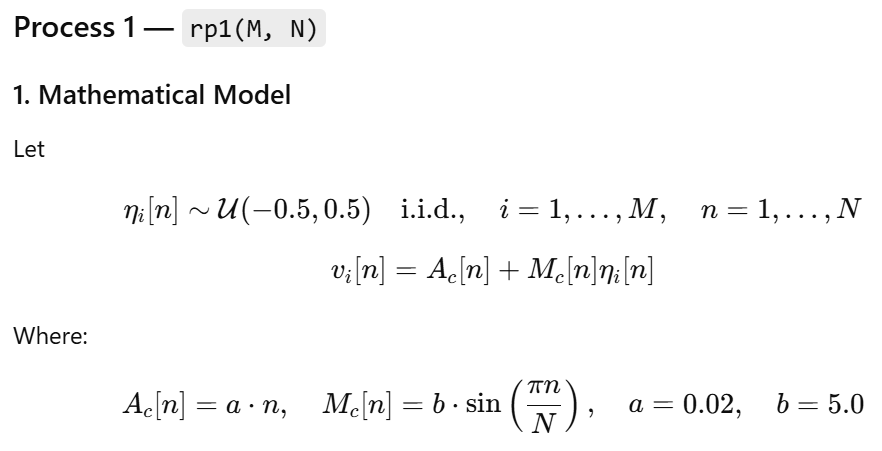
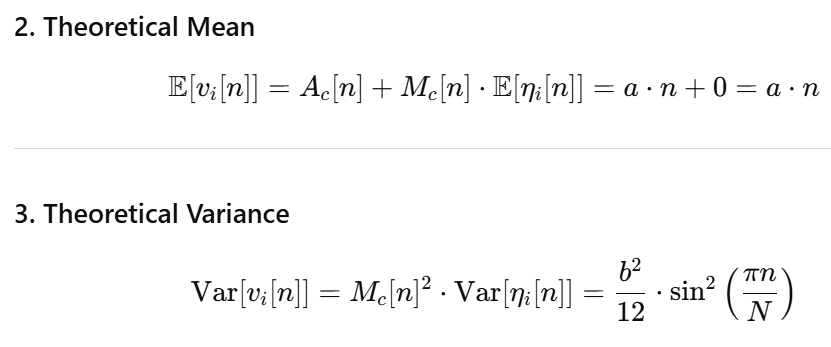
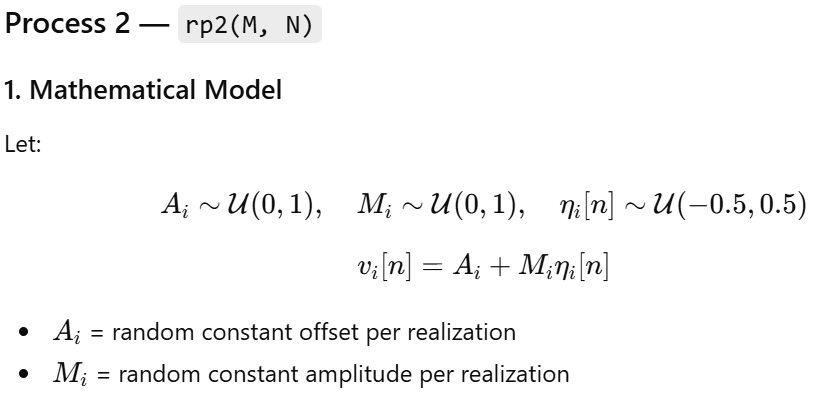
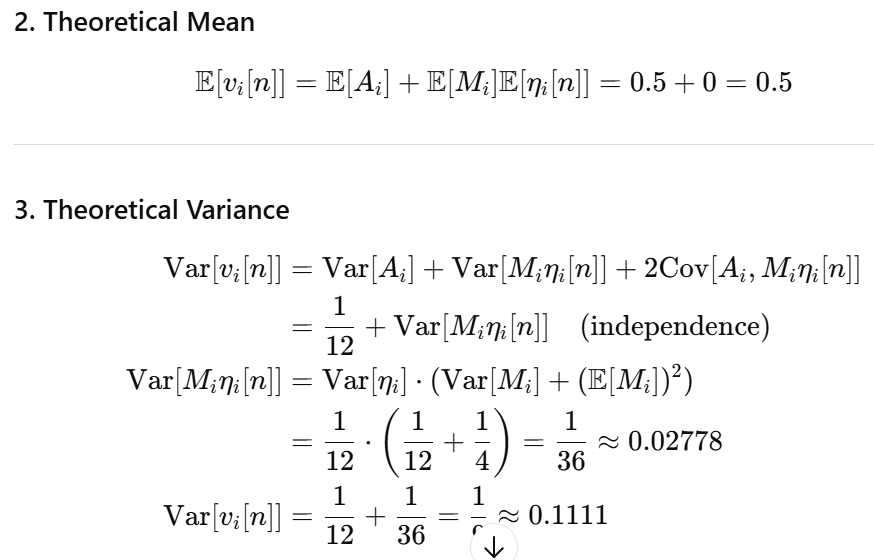
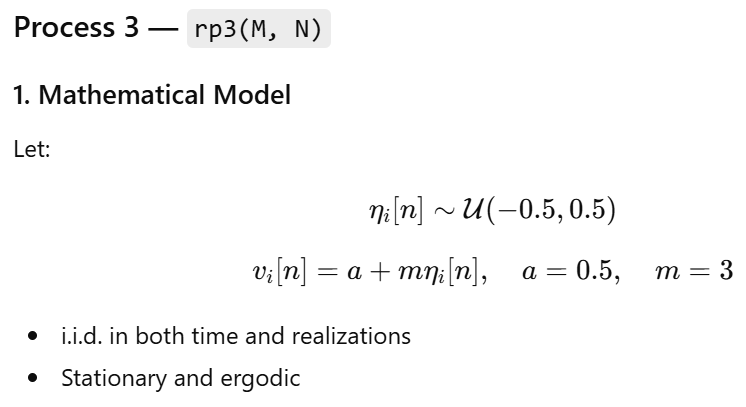
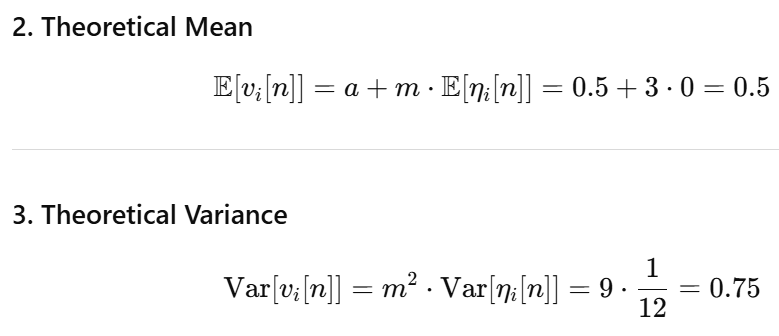

Process 1: Theoretical mean and variance behaviour can be observed in the results generated from sampling averaging.